# FDG PET SUVR ANCOVA: CEUNIM vs Control

This notebook:
1. Loads `PET_CERMEP_CEUNIM_merged.csv` from the project `data/` folder.
2. Shows the 3-cohort structure in the merged file.
3. Compares **CEUNIM LC vs CEUNIM Control** ROI SUVR values using ANCOVA with `sexo` and `edad` as covariates.
4. Applies FDR correction across ROIs.
5. Creates publication-style boxplots for significant ROIs.

In [1]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multitest import multipletests

pd.set_option("display.max_columns", 20)
sns.set_theme(style="whitegrid", context="talk")

In [2]:
# Resolve repository root from notebook location: code/python/pet/<this_notebook>.ipynb
repo_root = Path.cwd().resolve()
if repo_root.name.lower() == "pet":
    repo_root = repo_root.parents[2]

candidate_paths = [
    repo_root / "data" / "PET_CERMEP_CEUNIM_merged.csv",
    repo_root / "data" / "processed_pet" / "PET_CERMEP_CEUNIM_merged.csv",
]

csv_path = next((p for p in candidate_paths if p.exists()), None)
if csv_path is None:
    raise FileNotFoundError(
        "Could not find PET_CERMEP_CEUNIM_merged.csv in data/ or data/processed_pet/."
    )

df = pd.read_csv(csv_path)
print(f"Loaded: {csv_path}")
print(f"Shape: {df.shape}")
df.head()

Loaded: D:\Work\UNSAM\CovidProject\longcovid-neuroimaging-cohort\data\processed_pet\PET_CERMEP_CEUNIM_merged.csv
Shape: (90, 97)


,ID,Grupo,SITE,sexo,edad,TL-hippocampus-R,TL-hippocampus-L,TL-amygdala-R,TL-amygdala-L,TL-anterior-temporal-lobe-medial-part-R,...,insula-anterior-short-gyrus-L,insula-anterior-short-gyrus-R,insula-middle-short-gyrus-L,insula-middle-short-gyrus-R,insula-posterior-short-gyrus-L,insula-posterior-short-gyrus-R,insula-anterior-inferior-cortex-L,insula-anterior-inferior-cortex-R,insula-anterior-long-gyrus-L,insula-anterior-long-gyrus-R
0,sub-0001,Control,CERMEP,F,35.0,3.726049,3.590039,3.240181,3.156167,3.466816,...,5.119102,5.168744,4.488571,5.007762,4.354542,4.761235,4.003745,4.095196,4.284809,4.511542
1,sub-0002,Control,CERMEP,F,58.0,3.755504,3.517790,3.331046,3.207381,3.348144,...,5.087987,5.054956,4.690338,4.743050,4.293609,4.578359,4.012581,3.822362,4.148762,4.339397
2,sub-0003,Control,CERMEP,M,36.0,3.938731,3.580471,3.350933,3.358920,3.887345,...,4.885676,4.869569,4.725672,4.712037,4.188174,4.466138,3.900067,3.975405,4.232632,4.328701
3,sub-0004,Control,CERMEP,M,51.0,3.733548,3.881086,3.295037,3.226424,1.629180,...,5.323909,4.899589,4.794145,5.109914,4.016184,4.048976,4.219452,4.403613,3.956006,4.106127
4,sub-0005,Control,CERMEP,M,33.0,3.504838,3.612034,3.064479,3.115828,2.993222,...,4.982743,5.149198,4.295299,4.408221,4.460674,4.671486,3.933538,4.115317,4.229753,4.358721


In [3]:
required_cols = ["Grupo", "SITE", "sexo", "edad"]
missing_required = [c for c in required_cols if c not in df.columns]
if missing_required:
    raise ValueError(f"Missing required columns: {missing_required}")

cohort3 = np.select(
    [
        (df["SITE"].eq("CERMEP") & df["Grupo"].eq("Control")),
        (df["SITE"].eq("CEUNIM") & df["Grupo"].eq("Control")),
        (df["SITE"].eq("CEUNIM") & df["Grupo"].eq("LC")),
    ],
    [
        "CERMEP_Control",
        "CEUNIM_Control",
        "CEUNIM_LC",
    ],
    default="Other",
)

summary = (
    df.assign(cohort3=cohort3)
    .groupby(["SITE", "Grupo", "cohort3"], dropna=False)
    .size()
    .reset_index(name="n")
)
summary

,SITE,Grupo,cohort3,n
0,CERMEP,Control,CERMEP_Control,37
1,CEUNIM,Control,CEUNIM_Control,26
2,CEUNIM,LC,CEUNIM_LC,27


In [4]:
# CEUNIM-specific comparison requested: CEUNIM LC vs CEUNIM Control
compare_df = df.loc[
    (df["SITE"].eq("CEUNIM")) & (df["Grupo"].isin(["Control", "LC"]))
].copy()

compare_df["analysis_group"] = compare_df["Grupo"].map({"Control": "Control", "LC": "CEUNIM"})
compare_df["sexo"] = compare_df["sexo"].astype("category")
compare_df["edad"] = pd.to_numeric(compare_df["edad"], errors="coerce")

excluded = {"ID", "Grupo", "SITE", "sexo", "edad", "analysis_group"}
candidate_roi_cols = [c for c in compare_df.columns if c not in excluded]

roi_cols = []
for col in candidate_roi_cols:
    converted = pd.to_numeric(compare_df[col], errors="coerce")
    if converted.notna().sum() > 0:
        compare_df[col] = converted
        roi_cols.append(col)

print("N CEUNIM subjects for ANCOVA:")
print(compare_df["analysis_group"].value_counts(dropna=False))
print(f"Detected ROI SUVR columns: {len(roi_cols)}")

N CEUNIM subjects for ANCOVA:
analysis_group
CEUNIM     27
Control    26
Name: count, dtype: int64
Detected ROI SUVR columns: 92


In [5]:
records = []

for roi in roi_cols:
    sub = compare_df[["analysis_group", "sexo", "edad", roi]].dropna().copy()

    if sub["analysis_group"].nunique() < 2:
        continue
    if sub["sexo"].nunique() < 2:
        continue

    formula = f'Q("{roi}") ~ C(analysis_group) + C(sexo) + edad'
    model = ols(formula, data=sub).fit()
    anova_tbl = sm.stats.anova_lm(model, typ=2)

    group_term = "C(analysis_group)"
    if group_term not in anova_tbl.index:
        continue

    mean_control = sub.loc[sub["analysis_group"].eq("Control"), roi].mean()
    mean_ceunim = sub.loc[sub["analysis_group"].eq("CEUNIM"), roi].mean()

    records.append(
        {
            "ROI": roi,
            "n": len(sub),
            "F_group": anova_tbl.loc[group_term, "F"],
            "p_group": anova_tbl.loc[group_term, "PR(>F)"],
            "mean_control": mean_control,
            "mean_ceunim": mean_ceunim,
            "delta_ceunim_minus_control": mean_ceunim - mean_control,
        }
    )

results_df = pd.DataFrame(records).sort_values("p_group").reset_index(drop=True)

if len(results_df) > 0:
    rej, p_fdr, _, _ = multipletests(results_df["p_group"], alpha=0.05, method="fdr_bh")
    results_df["p_fdr"] = p_fdr
    results_df["significant_fdr"] = rej
else:
    results_df["p_fdr"] = pd.Series(dtype=float)
    results_df["significant_fdr"] = pd.Series(dtype=bool)

results_df.head(20)

,ROI,n,F_group,p_group,mean_control,mean_ceunim,delta_ceunim_minus_control,p_fdr,significant_fdr
0,TL-middle-and-inferior-temporal-gyrus-L,53,21.015264,0.000032,4.633929,4.843210,0.209282,0.001554,True
1,PL-supramarginal-gyrus-L,53,20.838231,0.000034,4.886907,5.162778,0.275871,0.001554,True
2,FL-superior-frontal-gyrus-R,53,19.241974,0.000061,4.897103,5.157118,0.260015,0.001871,True
3,FL-lateral-orbital-gyrus-L,53,17.932940,0.000100,5.134050,5.508743,0.374693,0.002307,True
4,FL-middle-frontal-gyrus-L,53,15.362345,0.000275,5.329678,5.686595,0.356917,0.004355,True
5,CG-anterior-cingulate-gyrus-R,53,15.049961,0.000312,4.376020,4.755339,0.379319,0.004355,True
6,FL-inferior-frontal-gyrus-L,53,14.905064,0.000331,5.242219,5.615461,0.373242,0.004355,True
7,FL-superior-frontal-gyrus-L,53,13.484498,0.000594,4.843167,5.148403,0.305236,0.006836,True
8,TL-posterior-temporal-lobe-L,53,11.563388,0.001346,4.836973,4.952040,0.115068,0.013761,True
9,TL-anterior-temporal-lobe-lateral-part-L,53,10.674180,0.001988,4.179812,4.354216,0.174404,0.018291,True


In [6]:
results_dir = repo_root / "data" / "results" / "pet_network_analysis"
results_dir.mkdir(parents=True, exist_ok=True)
results_csv = results_dir / "ancova_ceunim_vs_control_results.csv"
results_df.to_csv(results_csv, index=False)

signif_df = results_df.loc[results_df["significant_fdr"].eq(True)].copy()
print(f"Saved full ANCOVA table: {results_csv}")
print(f"Significant ROIs (FDR < 0.05): {len(signif_df)}")
signif_df[["ROI", "F_group", "p_group", "p_fdr", "delta_ceunim_minus_control"]].head(50)

Saved full ANCOVA table: D:\Work\UNSAM\CovidProject\longcovid-neuroimaging-cohort\data\results\pet_network_analysis\ancova_ceunim_vs_control_results.csv
Significant ROIs (FDR < 0.05): 13


,ROI,F_group,p_group,p_fdr,delta_ceunim_minus_control
0,TL-middle-and-inferior-temporal-gyrus-L,21.015264,0.000032,0.001554,0.209282
1,PL-supramarginal-gyrus-L,20.838231,0.000034,0.001554,0.275871
2,FL-superior-frontal-gyrus-R,19.241974,0.000061,0.001871,0.260015
3,FL-lateral-orbital-gyrus-L,17.932940,0.000100,0.002307,0.374693
4,FL-middle-frontal-gyrus-L,15.362345,0.000275,0.004355,0.356917
5,CG-anterior-cingulate-gyrus-R,15.049961,0.000312,0.004355,0.379319
6,FL-inferior-frontal-gyrus-L,14.905064,0.000331,0.004355,0.373242
7,FL-superior-frontal-gyrus-L,13.484498,0.000594,0.006836,0.305236
8,TL-posterior-temporal-lobe-L,11.563388,0.001346,0.013761,0.115068
9,TL-anterior-temporal-lobe-lateral-part-L,10.674180,0.001988,0.018291,0.174404


C:\Users\mabel\AppData\Local\Temp\ipykernel_12512\226425846.py:73: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(


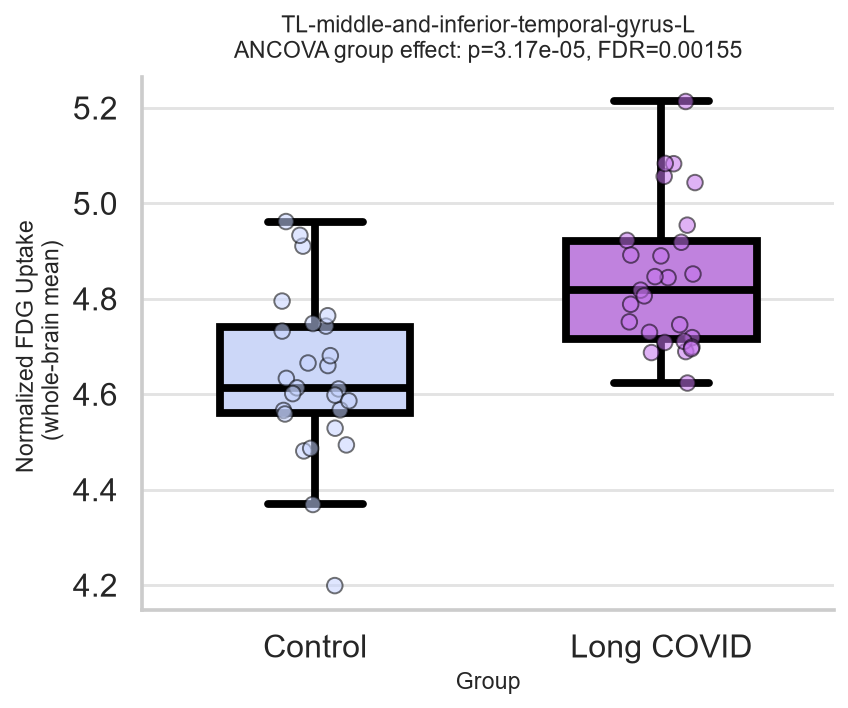

C:\Users\mabel\AppData\Local\Temp\ipykernel_12512\226425846.py:73: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(


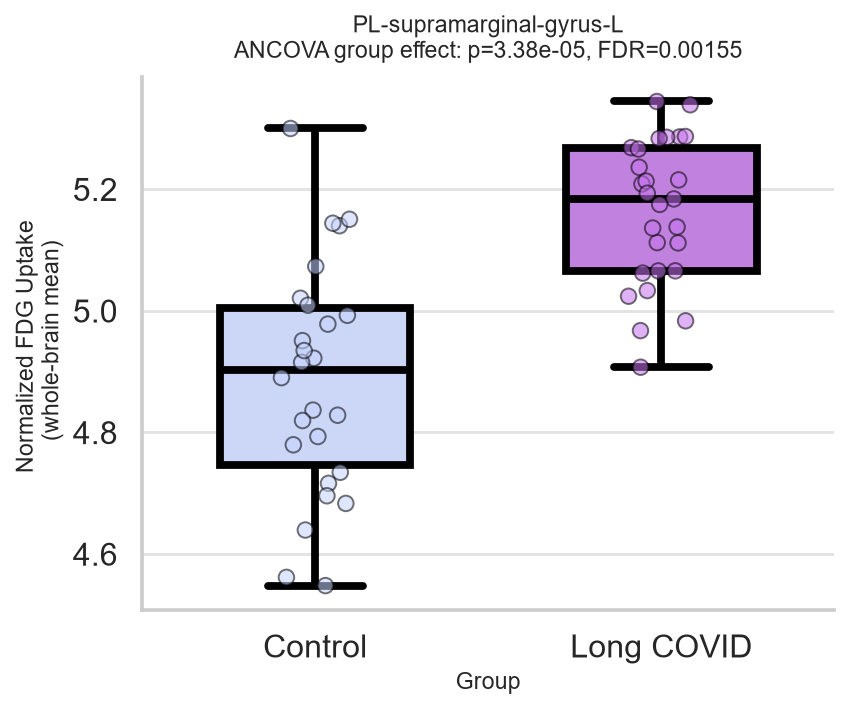

C:\Users\mabel\AppData\Local\Temp\ipykernel_12512\226425846.py:73: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(


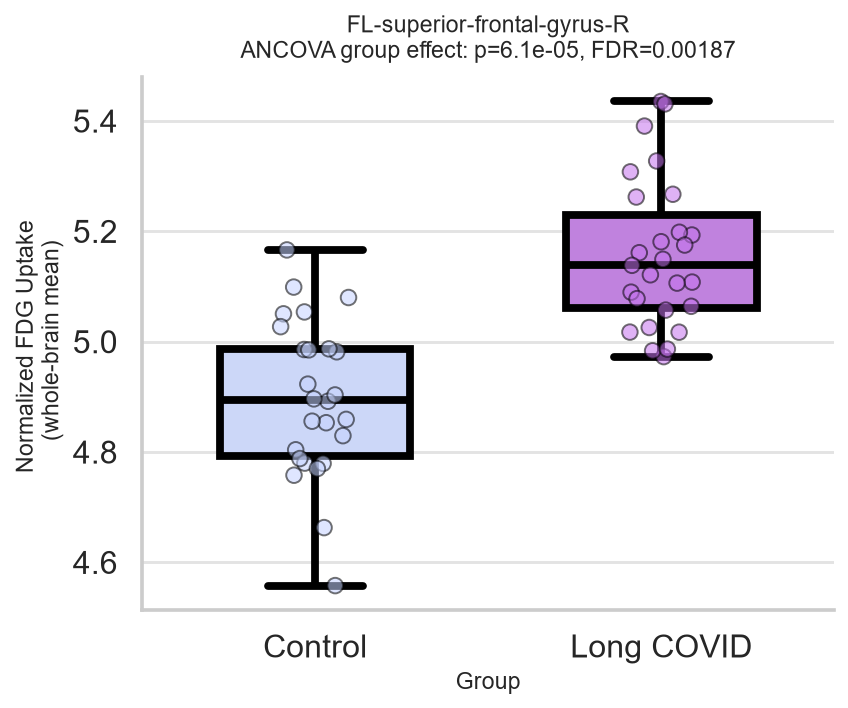

C:\Users\mabel\AppData\Local\Temp\ipykernel_12512\226425846.py:73: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(


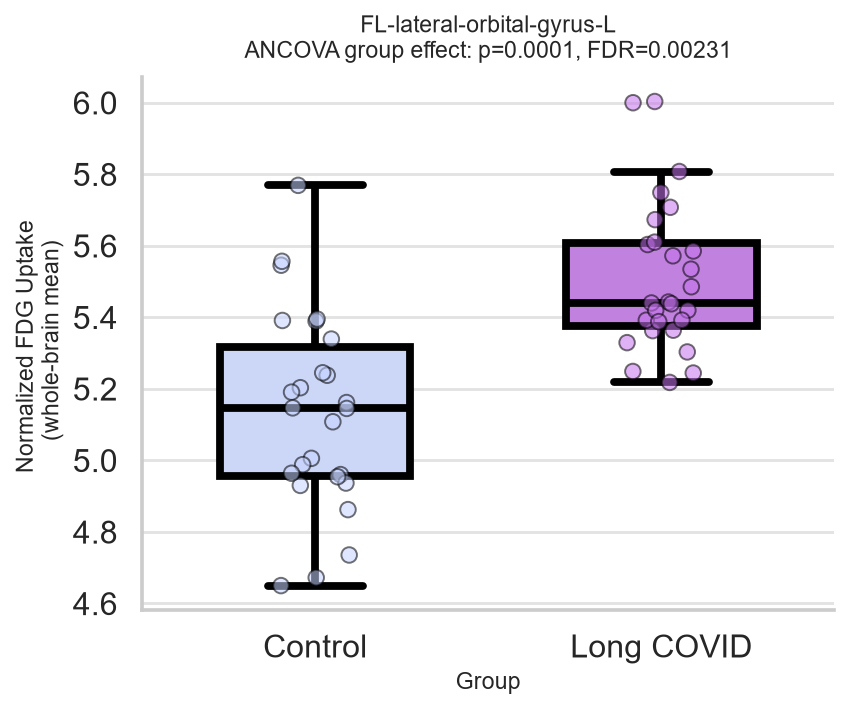

C:\Users\mabel\AppData\Local\Temp\ipykernel_12512\226425846.py:73: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(


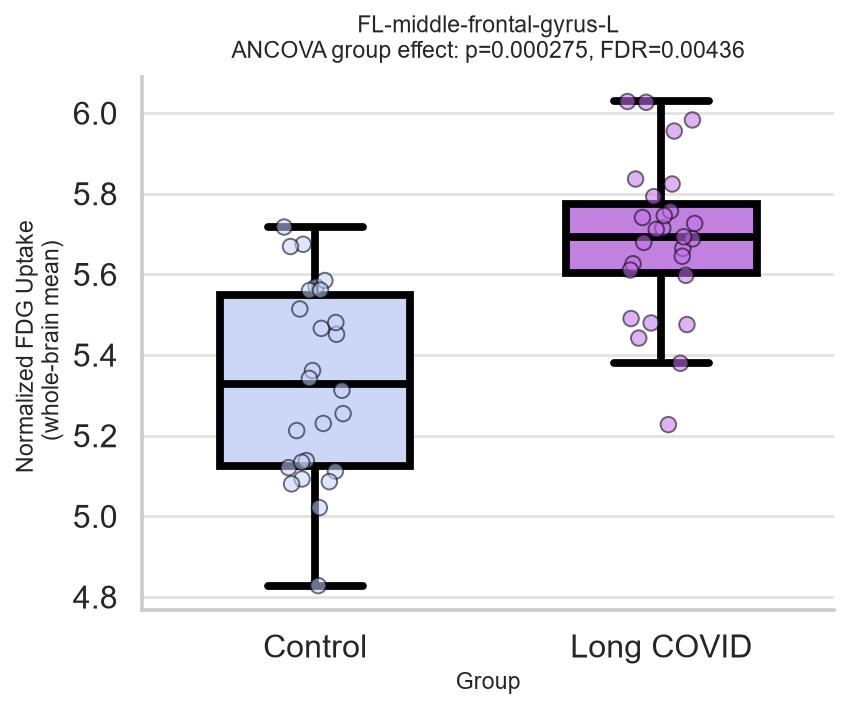

C:\Users\mabel\AppData\Local\Temp\ipykernel_12512\226425846.py:73: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(


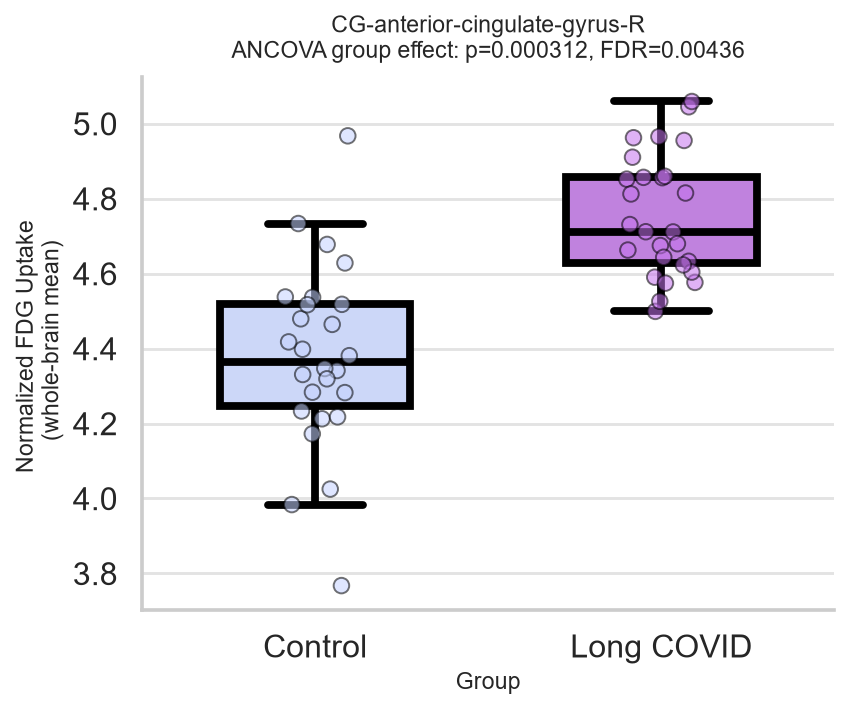

C:\Users\mabel\AppData\Local\Temp\ipykernel_12512\226425846.py:73: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(


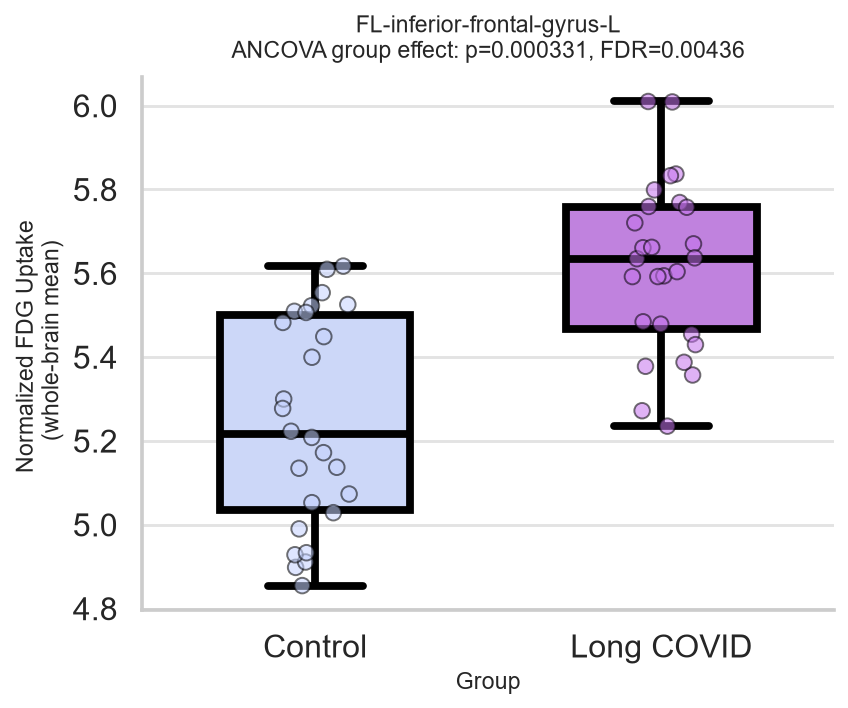

C:\Users\mabel\AppData\Local\Temp\ipykernel_12512\226425846.py:73: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(


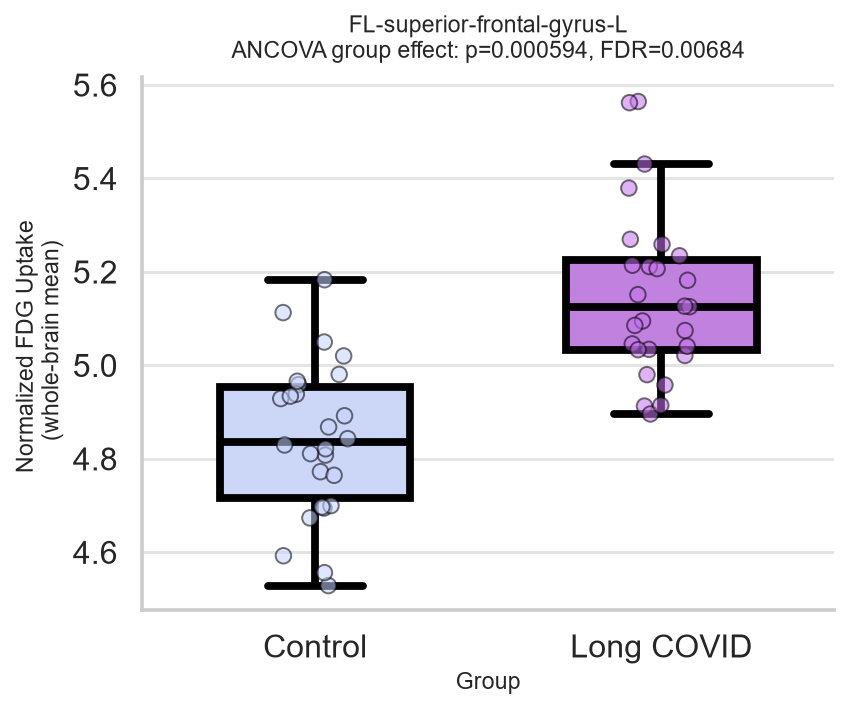

C:\Users\mabel\AppData\Local\Temp\ipykernel_12512\226425846.py:73: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(


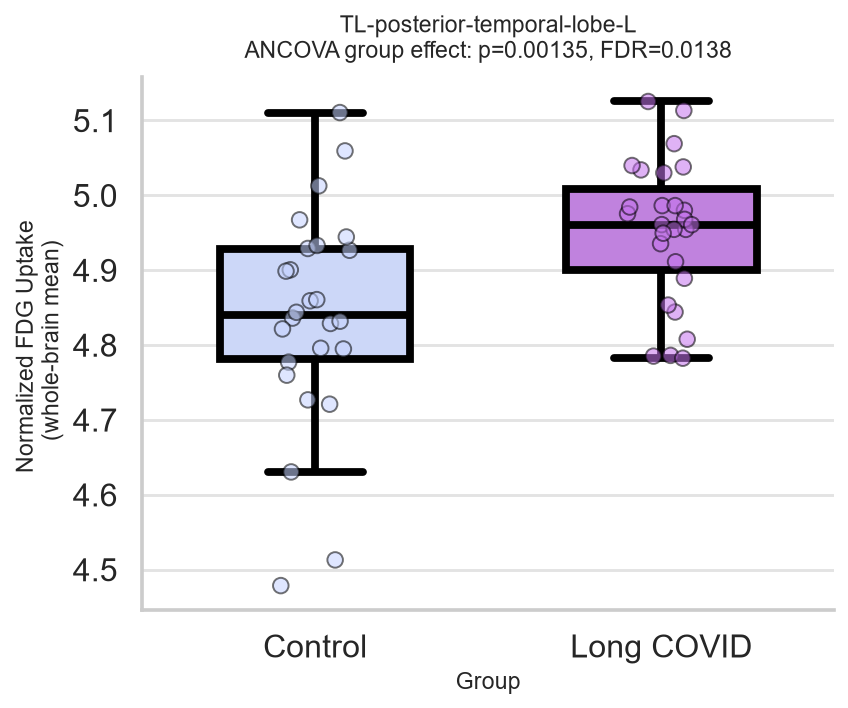

C:\Users\mabel\AppData\Local\Temp\ipykernel_12512\226425846.py:73: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(


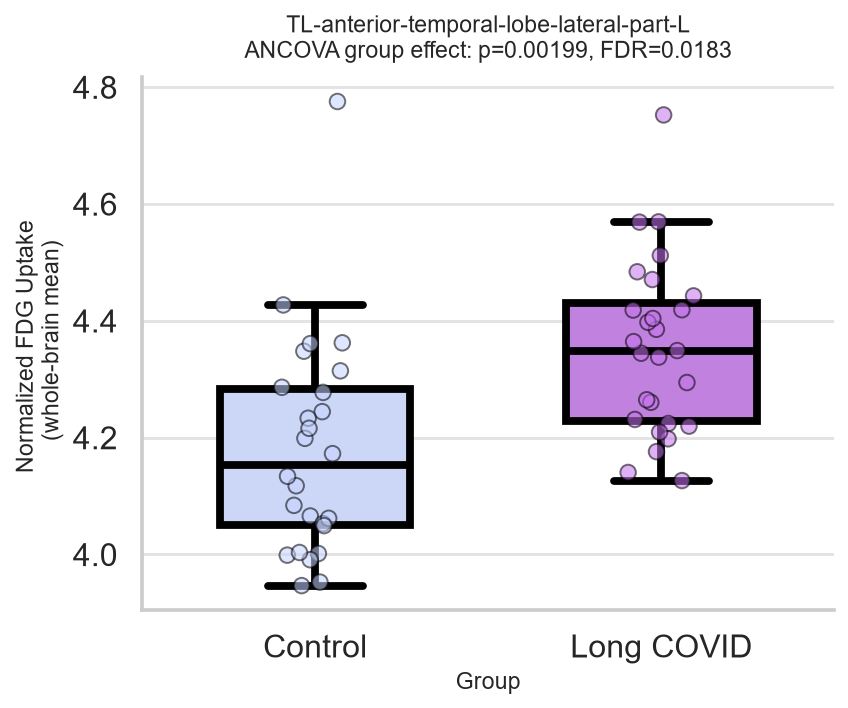

C:\Users\mabel\AppData\Local\Temp\ipykernel_12512\226425846.py:73: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(


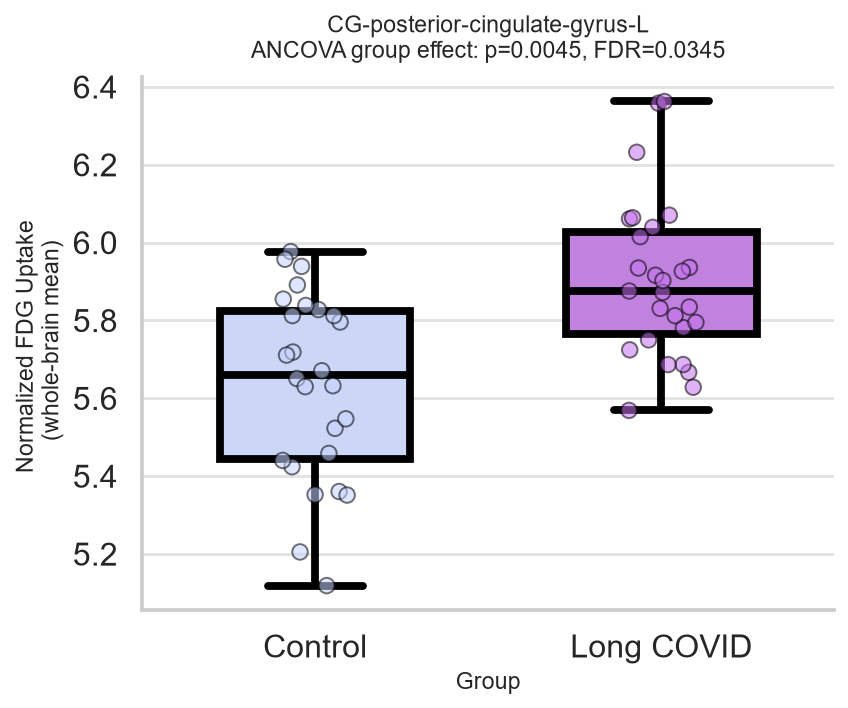

C:\Users\mabel\AppData\Local\Temp\ipykernel_12512\226425846.py:73: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(


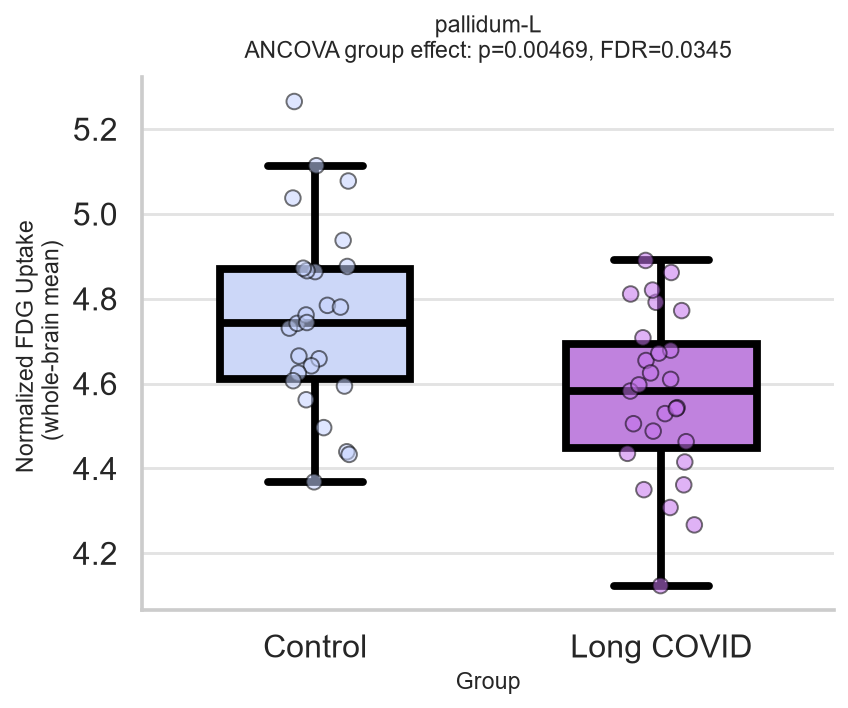

C:\Users\mabel\AppData\Local\Temp\ipykernel_12512\226425846.py:73: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(


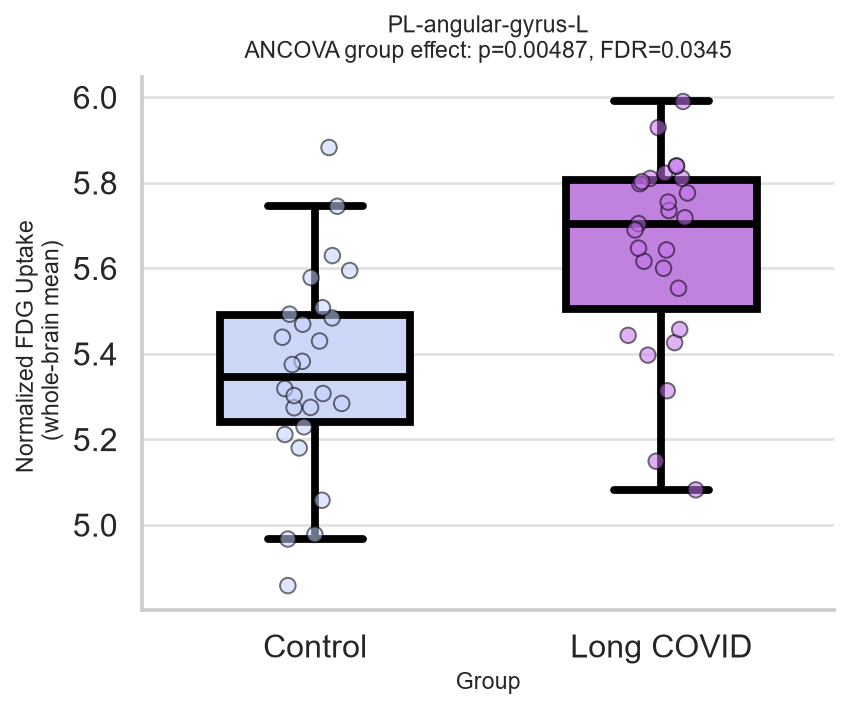

Saved 13 publication-style plots to: D:\Work\UNSAM\CovidProject\longcovid-neuroimaging-cohort\data\plots\pet_network_analysis\ancova_significant_rois


In [ ]:
plots_dir = repo_root / "results" / "pet_regional_analysis" / "plots" / "ancova_significant_rois"

plots_dir.mkdir(parents=True, exist_ok=True)



def clean_filename(name: str) -> str:

    return re.sub(r"[^A-Za-z0-9_.-]+", "_", name)





compare_df["analysis_group"] = compare_df["analysis_group"].replace(
    {"Control": "Control", "CEUNIM": "Long COVID"}
)

palette = {"Control": "#C5D3FF", "Long COVID": "#C573ED"}

if signif_df.empty:

    print("No significant ROIs after FDR correction. No plots generated.")

else:

    for _, row in signif_df.iterrows():

        roi = row["ROI"]

        sub = compare_df[["analysis_group", roi]].dropna().copy()



        fig, ax = plt.subplots(figsize=(6.4, 5.4), dpi=140)



        sns.boxplot(

            data=sub,

            x="analysis_group",

            y=roi,

            hue="analysis_group",

            order=["Control", "Long COVID"],

            hue_order=["Control", "Long COVID"],

            palette=palette,

            width=0.55,

            fliersize=0,

            linewidth=4,

            linecolor="black",

            dodge=False,

            legend=False,

            ax=ax,

        )



        sns.stripplot(

            data=sub,

            x="analysis_group",

            y=roi,

            order=["Control", "Long COVID"],

            hue_order=["Control", "Long COVID"],

            palette=palette,

            #color="#1A1A1A",
            
            edgecolor='black', linewidth=1,


            alpha=0.55,

            size=8,

            jitter=True,

            ax=ax,

        )



        ax.set_xlabel("Group", fontsize=12)

        ax.set_ylabel("Normalized FDG Uptake \n (whole-brain mean)", fontsize=12)

        ax.set_title(

            f"{roi}\nANCOVA group effect: p={row['p_group']:.3g}, FDR={row['p_fdr']:.3g}",

            fontsize=12,

            pad=10,

        )

        ax.spines["top"].set_visible(False)

        ax.spines["right"].set_visible(False)

        ax.grid(axis="y", alpha=0.55)



        plt.tight_layout()

        out_path = plots_dir / f"ancova_ceunim_vs_control_{clean_filename(roi)}.png"

        fig.savefig(out_path, dpi=300, bbox_inches="tight")

        plt.show()

        plt.close(fig)



    print(f"Saved {len(signif_df)} publication-style plots to: {plots_dir}")


## Notes
- If you want to compare CEUNIM LC against **all controls** (CERMEP + CEUNIM), adjust the `compare_df` filter accordingly.
- You can switch from FDR to uncorrected threshold by using `p_group < 0.05` instead of `significant_fdr`.